In [7]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
plt.rc("font", size=14)
import warnings 
warnings.filterwarnings("ignore")

# Q1)Dataset: Portuguese Dataset

In [2]:
df= pd.read_csv(r"Potuguesebank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
##1 Display structure and summary report.
print("Dataset Structure:\n")
df.info()

print("\n Summary Report:\n")
print(df.describe(include='all'))

Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

 Summary Report:

                 age          job  marital  education defaul

In [4]:
# checking for null values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
# calculating target variable values
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
# Convert target variable to binary (0 for 'no', 1 for 'yes')
df["y"] = df["y"].map({"no": 0, "yes": 1})

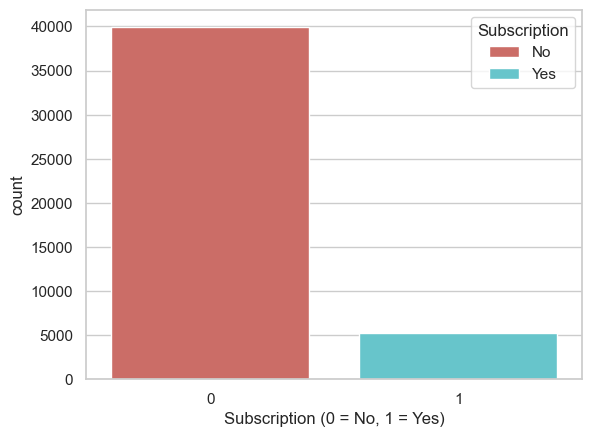

In [8]:
# Distribution of target variable
sns.countplot(x='y',data=df, palette='hls')
plt.xlabel("Subscription (0 = No, 1 = Yes)")
plt.legend(['No', 'Yes'], title="Subscription")
plt.show() 

In [9]:
# printing numerical column
print("\nNumerical Columns:\n")
categorical_columns = df.select_dtypes(include=['int64']).columns
print(categorical_columns)


Numerical Columns:

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y'],
      dtype='object')


In [10]:
# standardize numerical column
scaler= StandardScaler()
df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',]] = scaler.fit_transform(df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']])


In [11]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1.606965,management,married,tertiary,no,0.256419,yes,no,unknown,-1.298476,may,0.011016,-0.569351,-0.411453,-0.251940,unknown,0
1,0.288529,technician,single,secondary,no,-0.437895,yes,no,unknown,-1.298476,may,-0.416127,-0.569351,-0.411453,-0.251940,unknown,0
2,-0.747384,entrepreneur,married,secondary,no,-0.446762,yes,yes,unknown,-1.298476,may,-0.707361,-0.569351,-0.411453,-0.251940,unknown,0
3,0.571051,blue-collar,married,unknown,no,0.047205,yes,no,unknown,-1.298476,may,-0.645231,-0.569351,-0.411453,-0.251940,unknown,0
4,-0.747384,unknown,single,unknown,no,-0.447091,no,no,unknown,-1.298476,may,-0.233620,-0.569351,-0.411453,-0.251940,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,technician,married,tertiary,no,-0.176460,no,no,cellular,0.143418,nov,2.791329,0.076230,-0.411453,-0.251940,unknown,1
45207,2.831227,retired,divorced,primary,no,0.120447,no,no,cellular,0.143418,nov,0.768224,-0.246560,-0.411453,-0.251940,unknown,1
45208,2.925401,retired,married,secondary,no,1.429593,no,no,cellular,0.143418,nov,3.373797,0.721811,1.436189,1.050473,success,1
45209,1.512791,blue-collar,married,secondary,no,-0.228024,no,no,telephone,0.143418,nov,0.970146,0.399020,-0.411453,-0.251940,unknown,0


In [12]:
# printing categorical column
print("\nCategorical Columns:\n")
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)



Categorical Columns:

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [13]:
# Use one-hot encoding for `neighbourhood_group` and `room_type`
df1 = pd.get_dummies(df, columns=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome'], drop_first=True, dtype=int)

In [14]:
df1

,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,1.606965,0.256419,-1.298476,0.011016,-0.569351,-0.411453,-0.251940,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,0.288529,-0.437895,-1.298476,-0.416127,-0.569351,-0.411453,-0.251940,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,-0.747384,-0.446762,-1.298476,-0.707361,-0.569351,-0.411453,-0.251940,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,0.571051,0.047205,-1.298476,-0.645231,-0.569351,-0.411453,-0.251940,0,1,0,...,0,0,0,1,0,0,0,0,0,1
4,-0.747384,-0.447091,-1.298476,-0.233620,-0.569351,-0.411453,-0.251940,0,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.176460,0.143418,2.791329,0.076230,-0.411453,-0.251940,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45207,2.831227,0.120447,0.143418,0.768224,-0.246560,-0.411453,-0.251940,1,0,0,...,0,0,0,0,1,0,0,0,0,1
45208,2.925401,1.429593,0.143418,3.373797,0.721811,1.436189,1.050473,1,0,0,...,0,0,0,0,1,0,0,0,1,0
45209,1.512791,-0.228024,0.143418,0.970146,0.399020,-0.411453,-0.251940,0,1,0,...,0,0,0,0,1,0,0,0,0,1


In [15]:
correlation_matrix = df1.corr()
correlation_matrix["y"].sort_values(ascending=False)

y                      1.000000
duration               0.394521
poutcome_success       0.306788
month_mar              0.129456
month_oct              0.128531
month_sep              0.123185
pdays                  0.103621
previous               0.093236
job_retired            0.079245
job_student            0.076897
month_dec              0.075164
education_tertiary     0.066448
marital_single         0.063526
balance                0.052838
month_feb              0.038417
job_management         0.032919
poutcome_other         0.031955
age                    0.025155
job_unemployed         0.020390
contact_telephone      0.014042
education_unknown      0.012053
job_self-employed      0.000855
job_unknown            0.000267
month_aug             -0.008536
month_jan             -0.008783
job_technician        -0.008970
month_nov             -0.014937
job_housemaid         -0.015195
month_jun             -0.016805
job_entrepreneur      -0.019662
default_yes           -0.022419
job_serv

In [16]:
# Separate features and target variable
X = df1.drop(columns=["y"])
y = df1["y"]

In [17]:
# RFE(Recursive Feature Elimination)
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
rfe = RFE(estimator=logreg, n_features_to_select=18)
rfe = rfe.fit(X , y )
print(rfe.support_)
print(rfe.ranking_)

[False False False  True False False False False False False False  True
 False False  True False False False False False False  True  True False
  True  True False  True  True  True False  True  True  True  True False
  True  True  True False  True False]
[25 21 20  1  6 24 22 11  9  4 15  1 12 13  1 14 16 10  8 18  2  1  1 23
  1  1 17  1  1  1  7  1  1  1  1  3  1  1  1  5  1 19]


In [18]:
column_names = df1.drop(columns=['y']).columns

# Get the selected column names
selected_columns = column_names[rfe.support_]

# Print the selected column names
print(selected_columns)

Index(['duration', 'job_retired', 'job_student', 'education_tertiary',
       'education_unknown', 'housing_yes', 'loan_yes', 'contact_unknown',
       'month_aug', 'month_dec', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_nov', 'month_oct', 'month_sep', 'poutcome_success'],
      dtype='object')


In [19]:
cols = ['duration', 'job_retired', 'job_student', 'education_tertiary',
       'education_unknown', 'housing_yes', 'loan_yes', 'contact_unknown',
       'month_aug', 'month_dec', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_nov', 'month_oct', 'month_sep', 'poutcome_success']
X = df1[cols]
y = df1["y"]

In [22]:
#Implementing the model logit function 
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.263968
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45193
Method:                           MLE   Df Model:                           17
Date:                Wed, 05 Mar 2025   Pseudo R-squ.:                  0.2685
Time:                        14:08:13   Log-Likelihood:                -11934.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
duration               1.0634      0.016     64.909      0.000       1.031       1.095
job_r

### Logistic Regression Model Fitting

In [23]:
# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [24]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [25]:
y_pred = logreg.predict(X_test)

In [26]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.90


### Cross Validation

In [27]:
kfold = model_selection.KFold(n_splits=10, random_state=7,shuffle=True)
modelCV = LogisticRegression()
scoring = 'accuracy'
results = model_selection.cross_val_score(modelCV, X_train, y_train, cv=kfold, scoring=scoring)
print("10-fold cross validation average accuracy: %.3f" % (results.mean()))

10-fold cross validation average accuracy: 0.903


### Confusion Matrix

In [28]:
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[7755  225]
 [ 683  380]]


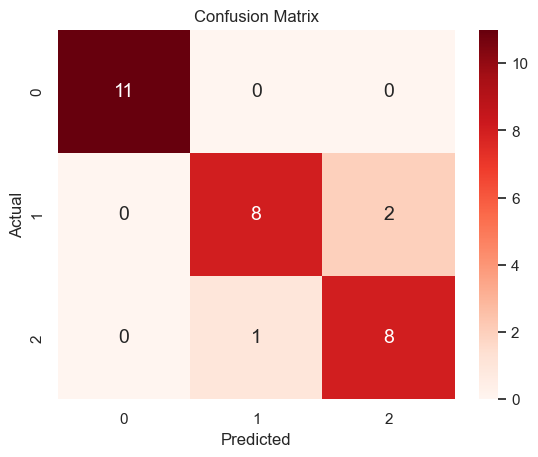

In [106]:
#confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt = "d", cmap= "Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7980
           1       0.63      0.36      0.46      1063

    accuracy                           0.90      9043
   macro avg       0.77      0.66      0.70      9043
weighted avg       0.88      0.90      0.89      9043



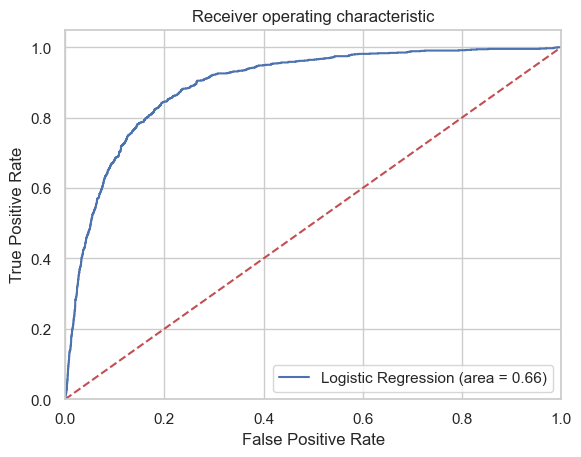

In [31]:
# ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Q2) Dataset: Titanic Datase

In [36]:
df2 = pd.read_csv(r"train.csv")
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
##1 Display structure and summary report:

print("Dataset Structure:\n")
df2.info()

print("\n Summary Report:\n")
print(df2.describe(include='all'))


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

 Summary Report:

        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN      

In [38]:
##3 Display NULL values for each of the columns:
print("\nNULL Values in Each Column:\n")
print(df2.isnull().sum())


NULL Values in Each Column:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [39]:
df2.drop(columns=["Cabin","Name","Ticket"], inplace= True)

In [40]:
df2

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [41]:
# Convert 'sex' to binary values
df2['Sex'] = df2['Sex'].map({'male': 1, 'female': 0})

In [42]:
df2_new = df2.select_dtypes(exclude=["object"]).columns
df2_new= df2[df2_new]

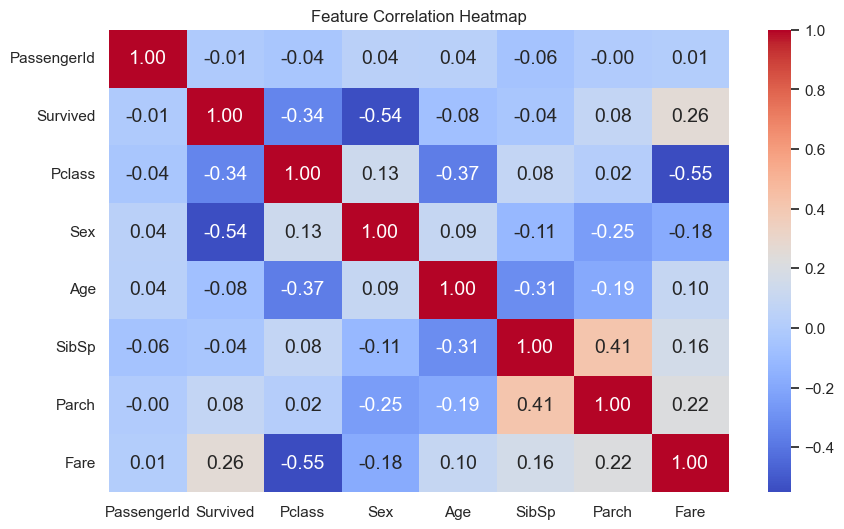

In [43]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df2_new.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


In [44]:
correlation_matrix = df2_new.corr()
correlation_matrix["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Sex           -0.543351
Name: Survived, dtype: float64

In [45]:
# calculating target variable values
df2['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

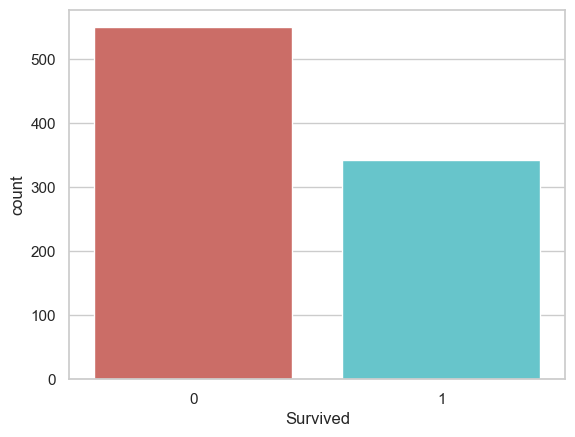

From the above countplot we can see that the number of persons survived are less



In [46]:
# Distribution of target variable
sns.countplot(x='Survived',data=df2, palette='hls')
plt.show()
print("From the above countplot we can see that the number of persons survived are less\n")


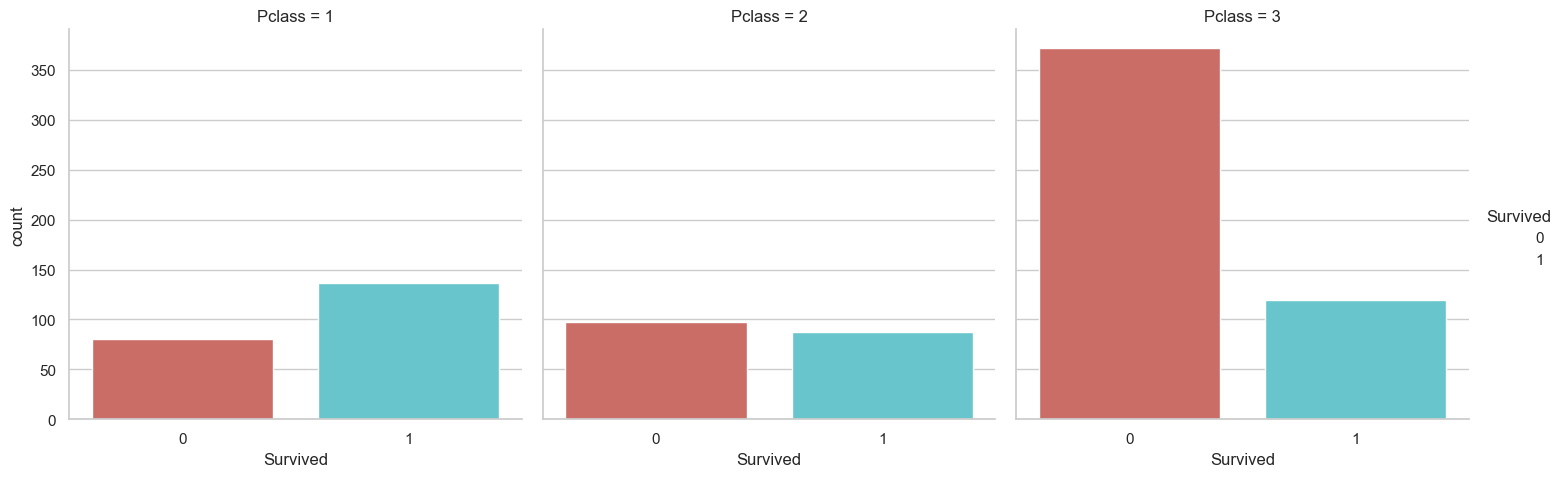

In [47]:
#Survival based on Pclass - Passenger Class
sns.catplot(x='Survived', col='Pclass', kind='count', data=df2, palette="hls");
plt.show()

In [48]:
# replacing null values with mean
df2.fillna(df2['Age'].mean(), inplace = True)
df2.fillna(df2['Fare'].mean(), inplace = True)

In [49]:
# checking for null values
df2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [50]:
# checking for duplicate values
df= pd.DataFrame(df2)
duplicated = df.duplicated()
print(df[duplicated])

Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Sex, Age, SibSp, Parch, Fare, Embarked]
Index: []


In [51]:
# encoding categorical variable
data = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

In [52]:
data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.000000,1,0,7.2500,0,0,1
1,2,1,1,0,38.000000,1,0,71.2833,1,0,0
2,3,1,3,0,26.000000,0,0,7.9250,0,0,1
3,4,1,1,0,35.000000,1,0,53.1000,0,0,1
4,5,0,3,1,35.000000,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,0,0,13.0000,0,0,1
887,888,1,1,0,19.000000,0,0,30.0000,0,0,1
888,889,0,3,0,29.699118,1,2,23.4500,0,0,1
889,890,1,1,1,26.000000,0,0,30.0000,1,0,0


In [53]:
data.drop(columns="PassengerId",inplace= True)

In [54]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.000000,1,0,7.2500,0,0,1
1,1,1,0,38.000000,1,0,71.2833,1,0,0
2,1,3,0,26.000000,0,0,7.9250,0,0,1
3,1,1,0,35.000000,1,0,53.1000,0,0,1
4,0,3,1,35.000000,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,0,0,1
887,1,1,0,19.000000,0,0,30.0000,0,0,1
888,0,3,0,29.699118,1,2,23.4500,0,0,1
889,1,1,1,26.000000,0,0,30.0000,1,0,0


In [55]:
# Separate features and target variable
X = data.drop(columns=["Survived"])
y = data["Survived"]

In [56]:
import statsmodels.api as sm
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.446236
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      882
Method:                           MLE   Df Model:                            8
Date:                Wed, 05 Mar 2025   Pseudo R-squ.:                  0.3299
Time:                        14:09:27   Log-Likelihood:                -397.60
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.255e-79
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Pclass        -0.9998      0.141     -7.067      0.000      -1.277      -0.723
Sex           -2.6986      0.

### Logistic Regression Model Fitting

In [57]:
# Feature scaling
scaler = StandardScaler()
data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q','Embarked_S','Embarked_C']] = scaler.fit_transform(data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q','Embarked_S','Embarked_C']])


In [58]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [59]:
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [60]:
y_pred = logreg.predict(X_test)

In [61]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1], dtype=int64)

In [62]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.80


### Confusion Matrix

In [63]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print("Confusion Matrix:\n")
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

Confusion Matrix:

[[90 15]
 [21 53]]


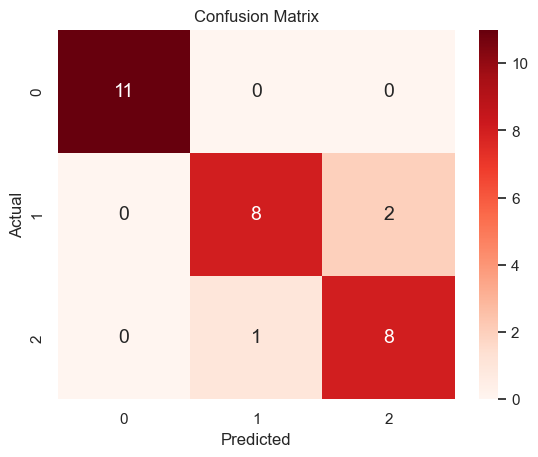

In [105]:
#confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt = "d", cmap= "Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



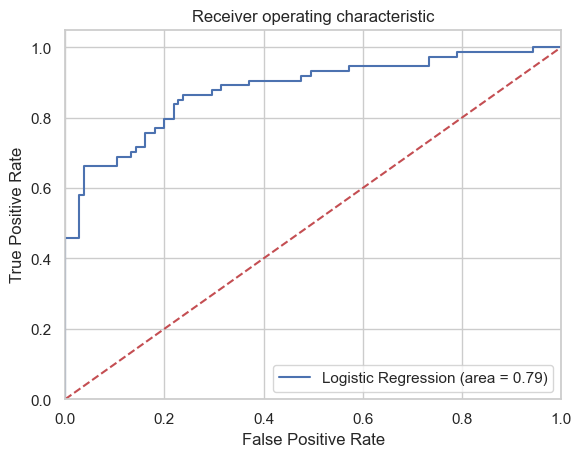

In [66]:
# ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Q3) Dataset : IRIS Dataset

In [67]:
df3 = pd.read_csv(r"iris.csv")
df3.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [68]:
##1 Display structure and summary report:

print("Dataset Structure:\n")
df3.info()

print("\n Summary Report:\n")
print(df3.describe(include='all'))


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

 Summary Report:

        sepal_length  sepal_width  petal_length  petal_width species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN           NaN          NaN  setosa
freq             NaN          NaN           NaN          NaN      50
mean        5.843333     3.054000      3.758667     1.198667     NaN
std         0.828066     0.433594      1.764420     0.763161     NaN
min         4.300000 

In [69]:
# checking for null values
df3.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [70]:
df3.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [71]:
df= pd.DataFrame(df3)
duplicated = df.duplicated()
print(df[duplicated])

     sepal_length  sepal_width  petal_length  petal_width    species
34            4.9          3.1           1.5          0.1     setosa
37            4.9          3.1           1.5          0.1     setosa
142           5.8          2.7           5.1          1.9  virginica


In [72]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [73]:
df = df.drop_duplicates(keep='first')
print(df)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[147 rows x 5 columns]


In [74]:
df['species'].value_counts()

species
versicolor    50
virginica     49
setosa        48
Name: count, dtype: int64

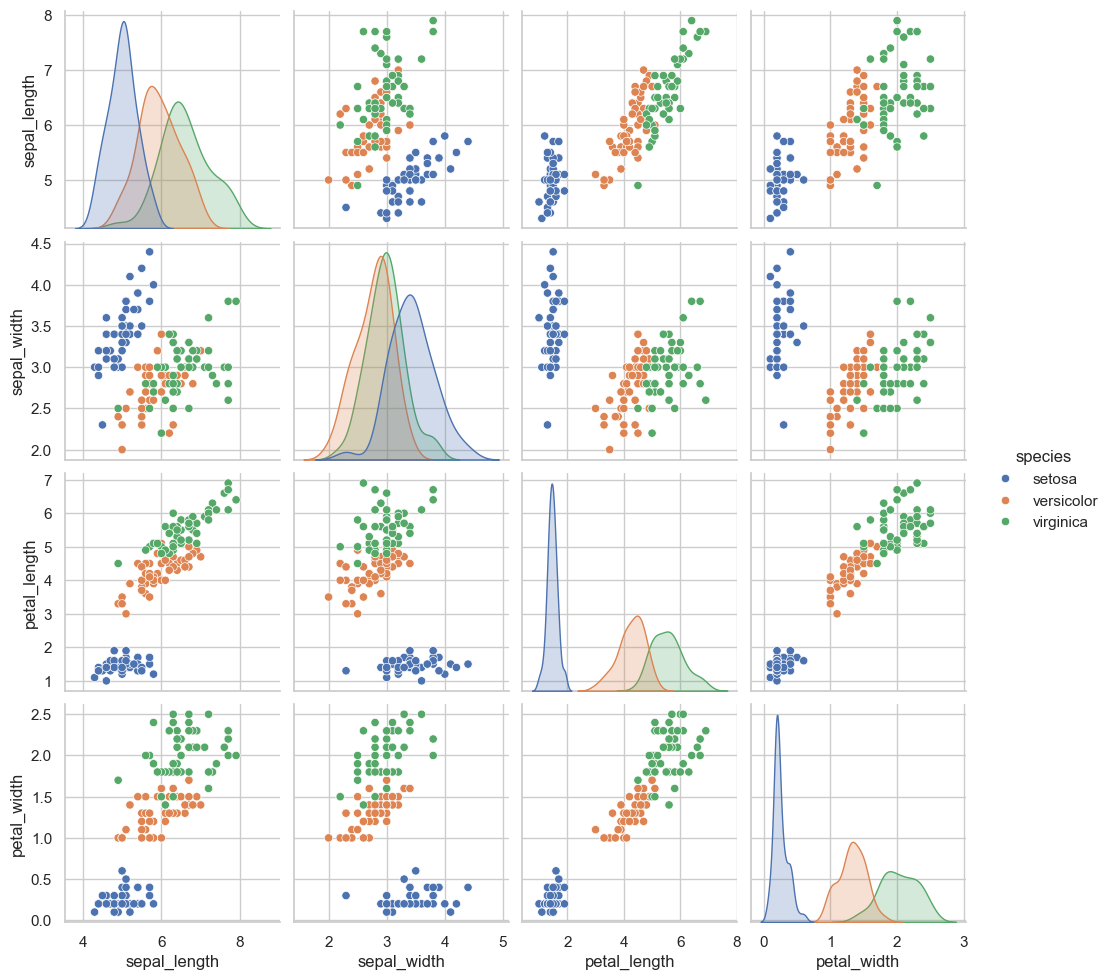

In [75]:
# EDA
sns.pairplot(df, hue='species', diag_kind='kde') # pairwise relationships in dataset
plt.show()

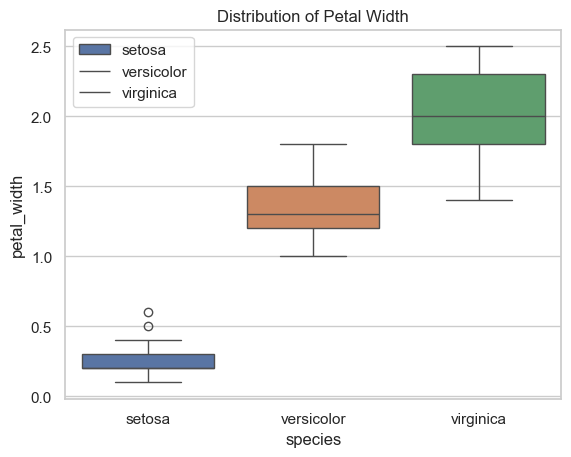

In [76]:
# Boxplot
sns.boxplot(x='species',y='petal_width',data=df,hue='species')
plt.title("Distribution of Petal Width")
plt.legend(['setosa','versicolor','virginica'])
plt.show();


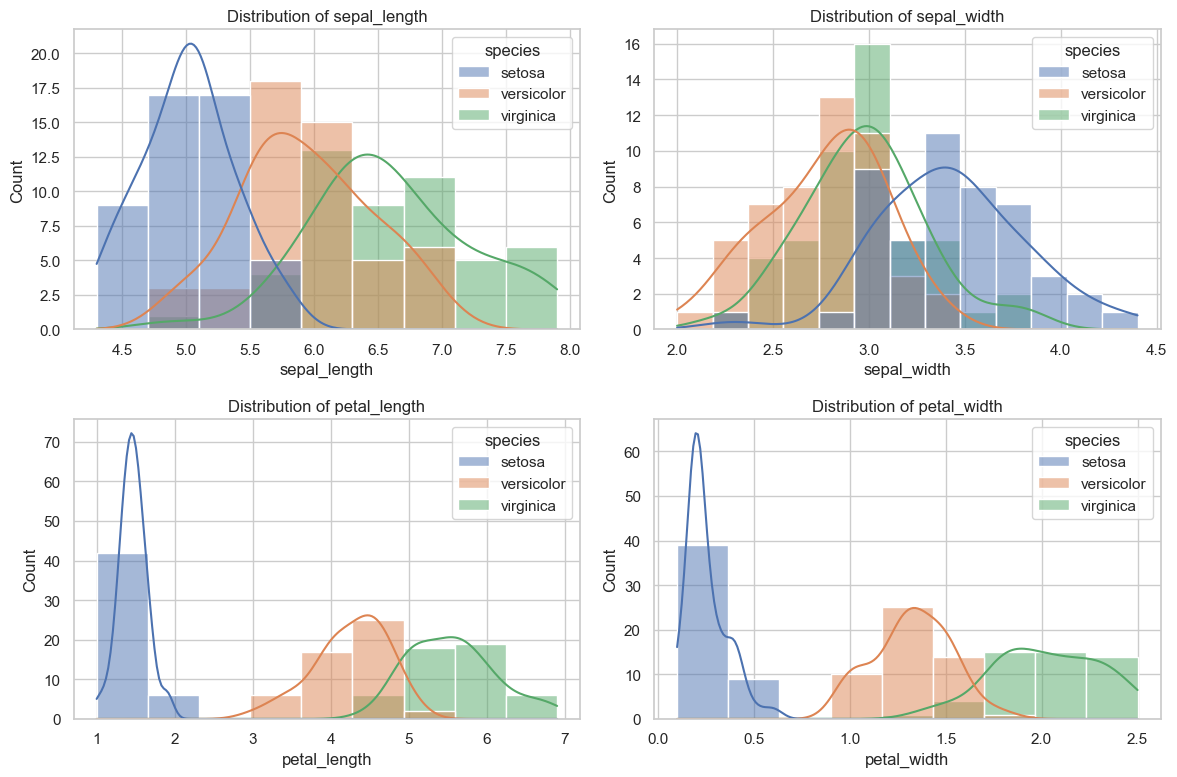

In [77]:
# Distribution plots for each numerical feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
for i, ax in enumerate(axes.flat):
    sns.histplot(df, x=features[i], hue="species", kde=True, ax=ax)
    ax.set_title(f"Distribution of {features[i]}")
plt.tight_layout()
plt.show()

In [78]:
# Transform the 'species' column
le = LabelEncoder()
df.loc[:,"species"] = le.fit_transform(df["species"])

In [79]:
# Print the mapping of species to encoded values
species_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(species_mapping)

{'setosa': 0, 'versicolor': 1, 'virginica': 2}


In [80]:
print(df['species'].value_counts())

species
1    50
2    49
0    48
Name: count, dtype: int64


In [81]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


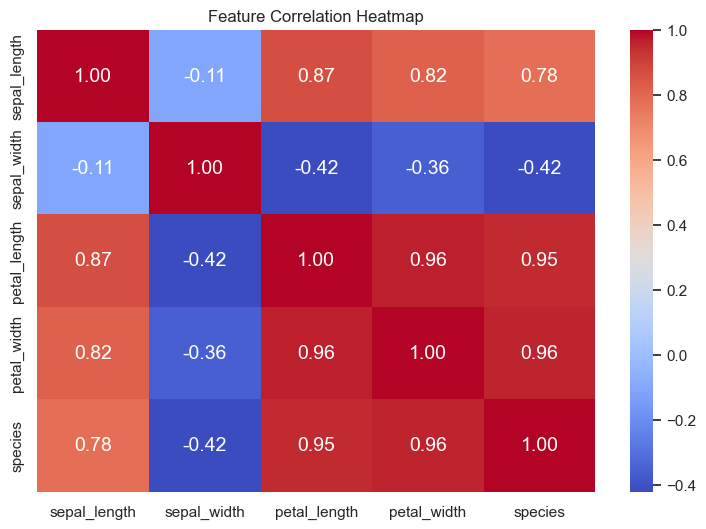

In [82]:
# Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [83]:
# Feature scaling
scaler = StandardScaler()
df.loc[:,['sepal_length', 'sepal_width', 'petal_length', 'petal_width']] = scaler.fit_transform(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])


In [84]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.915509,1.019971,-1.357737,-1.335700,0
1,-1.157560,-0.128082,-1.357737,-1.335700,0
2,-1.399610,0.331139,-1.414778,-1.335700,0
3,-1.520635,0.101529,-1.300696,-1.335700,0
4,-1.036535,1.249582,-1.357737,-1.335700,0
...,...,...,...,...,...
145,1.020892,-0.128082,0.809831,1.444682,2
146,0.536792,-1.276136,0.695748,0.915085,2
147,0.778842,-0.128082,0.809831,1.047484,2
148,0.415766,0.790361,0.923913,1.444682,2


In [85]:
# Separate features and target variable
X = df.drop(columns=["species"])
y = df["species"]

In [86]:
# Convert the target variable to integer type
y = y.astype("int")

### Logistic Regression Model Fitting

In [87]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [88]:
logreg = LogisticRegression(multi_class="ovr", solver="liblinear", random_state=42)
logreg.fit(X_train, y_train)

LogisticRegression(multi_class='ovr', random_state=42, solver='liblinear')

In [89]:
y_pred = logreg.predict(X_test)

In [90]:
y_pred

array([2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 1, 2, 1, 0, 1, 2, 0, 0, 2,
       0, 2, 1, 0, 1, 2, 2, 0])

In [91]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.90


### Confusion Matrix

In [92]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print("Confusion Matrix:\n")
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

Confusion Matrix:

[[11  0  0]
 [ 0  8  2]
 [ 0  1  8]]


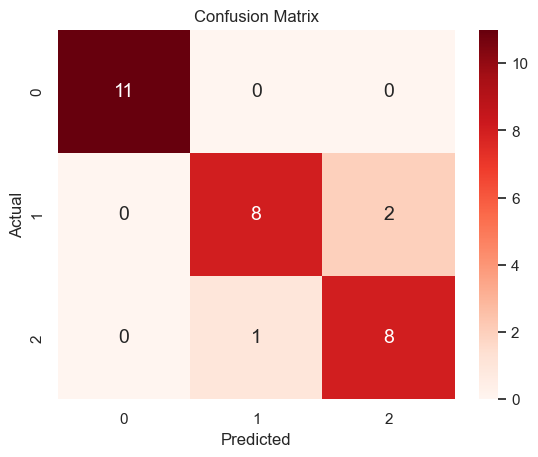

In [104]:
#confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt = "d", cmap= "Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [94]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.89      0.80      0.84        10
           2       0.80      0.89      0.84         9

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.89        30
weighted avg       0.90      0.90      0.90        30



Overall AUC score: 0.9915696649029982


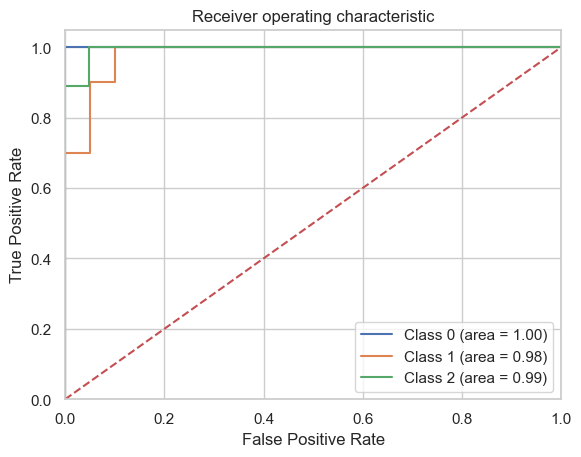

In [96]:
# ROC Curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# Calculate the ROC AUC score for multi-class classification
logit_roc_auc = roc_auc_score(y_test, logreg.predict_proba(X_test), multi_class='ovr')
print("Overall AUC score:", logit_roc_auc)

# dictionaries to store false positive rate (fpr), true positive rate (tpr) and thresholds
fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC curve and ROC area for each class
for i in range(len(logreg.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test, logreg.predict_proba(X_test)[:, i], pos_label=logreg.classes_[i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot the ROC curve    
plt.figure()
for i in range(len(logreg.classes_)):
    plt.plot(fpr[i], tpr[i], label='Class %d (area = %0.2f)' % (i, roc_auc[i]))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()